# Running the Toy Model on Cryosphere Data

### Source

North Greenland Ice Core Project

**Greenland Ice Core Chronology 2005 (GICC05) and 20 year means of oxygen isotope data from ice core NGRIP**

Andersen, Katrine K; Bigler, Matthias; Buchardt, Susanne L; Clausen, Henrik Brink; Dahl-Jensen, Dorthe; Davies, Siwan M; Fischer, Hubertus; Goto-Azuma, Kumiko; Hansson, Margareta E; Heinemeier, Jan; Johnsen, Sigfús Jóhann; Larsen, L B; Muscheler, Raimund; Olsen, G J; Rasmussen, Sune Olander; Röthlisberger, Regine; Ruth, Urs; Seierstad, Inger K; Siggaard-Andersen, Marie-Louise; Steffensen, Jørgen Peder; Svensson, Anders M; Vinther, Bo Møllesøe (2007). PANGAEA, https://doi.org/10.1594/PANGAEA.586838

### Coverage

Latitude: 75.100000

Longitude: -42.320000


Date/Time Start: 1996-07-01 T00:00:00

Date/Time End: 1996-07-01 T00:00:00


Minimum DEPTH, ice/snow: 7.35 m

Maximum DEPTH, ice/snow: 2128.48 m

In [37]:
import numpy as np
from ripser import ripser
import matplotlib.pyplot as plt
import pandas as pd

path = "/Users/jeffff/Desktop/AT2P/AT2P/Data/NGRIP_chronology_20.tab"

with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

header_idx = None
for i, line in enumerate(lines):
    if line.startswith("Age [ka BP]"):
        header_idx = i
        break

if header_idx is None:
    raise ValueError("Could not find header.")
    
df = pd.read_csv(
    path,
    sep="\t",
    skiprows=header_idx,
    engine="python"
)

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Rename
df = df.rename(columns={
    "Age [ka BP]": "age",
    "δ18O H2O [‰ SMOW]": "d18O"
})

# ka BP -> years BP
df["age"] = df["age"] * 1000

# Sort by age
df = df.sort_values("age").reset_index(drop=True)

print(df.head())
print(df.columns)
print(df.shape)

    age  Depth ice/snow [m]  Age e [±]   d18O
0 -30.0                7.35      0.001 -35.16
1 -10.0               14.15      0.001 -35.82
2  10.0               20.40      0.001 -35.11
3  30.0               26.10      0.001 -34.65
4  50.0               31.53      0.001 -34.53
Index(['age', 'Depth ice/snow [m]', 'Age e [±]', 'd18O'], dtype='object')
(2088, 4)


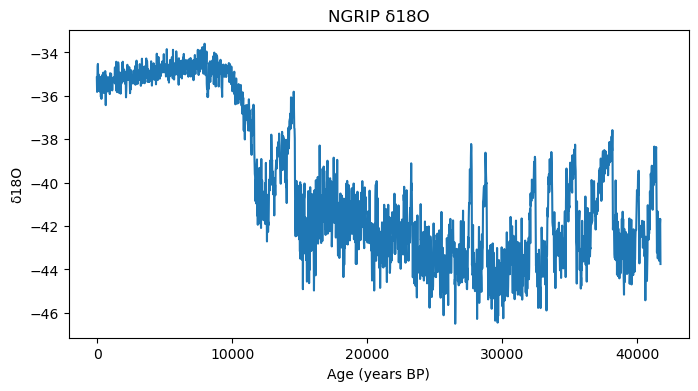

In [38]:
plt.figure(figsize=(8,4))
plt.plot(df["age"], df["d18O"])
plt.xlabel("Age (years BP)")
plt.ylabel("δ18O")
plt.title("NGRIP δ18O")
plt.show()

## Zoom into one Dansgaard-Oeschger (DO) event

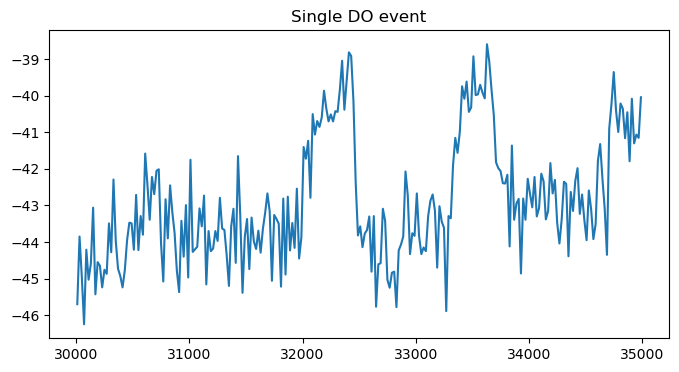

In [39]:
mask = (df["age"] > 30000) & (df["age"] < 35000)

t_sub = df["age"][mask].values
x_sub = df["d18O"][mask].values

plt.figure(figsize=(8,4))
plt.plot(t_sub, x_sub)
plt.title("Single DO event")
plt.show()

In [54]:
def delay_embedding(series, delay=5, dim=3):
    n = len(series) - (dim - 1) * delay
    if n <= 0:
        raise ValueError("Time series too short")
    return np.array([
        [series[i + j * delay] for j in range(dim)]
        for i in range(n)
    ])

def pers_feat(point_cloud, maxdim=1, q=0.9):
    """Compute persistence features from a point cloud."""
    dgms = ripser(point_cloud, maxdim=maxdim)["dgms"]

    h0 = dgms[0]
    h1 = dgms[1] if len(dgms) > 1 else np.empty((0, 2))

    # H0
    if len(h0) > 0:
        finite_h0 = h0[np.isfinite(h0[:, 1])]
        pers0 = finite_h0[:, 1] - finite_h0[:, 0] if len(finite_h0) > 0 else np.array([])
        h0_total = np.sum(pers0) if len(pers0) > 0 else 0.0
        h0_max   = np.max(pers0) if len(pers0) > 0 else 0.0
    else:
        h0_total = 0.0
        h0_max   = 0.0

    # H1
    if len(h1) > 0:
        pers1 = h1[:, 1] - h1[:, 0]
        h1_total = np.sum(pers1)
        h1_max   = np.max(pers1)

        # adaptive threshold only "strong" loops
        thresh = np.quantile(pers1, q)
        h1_strong_total = np.sum(pers1[pers1 >= thresh])
        h1_strong_count = np.sum(pers1 >= thresh)
    else:
        pers1 = np.array([])
        h1_total = 0.0
        h1_max = 0.0
        h1_strong_total = 0.0
        h1_strong_count = 0

    return {
        "h0_total": h0_total,
        "h0_max": h0_max,
        "h1_total": h1_total,
        "h1_max": h1_max,
        "h1_strong_total": h1_strong_total,
        "h1_strong_count": h1_strong_count,
        "dgms": dgms,
    }

def windowed_topo(series, times, window_size=300, step=30, delay=5, embed_dim=3):
    """Compute windowed topological features from a time series."""
    centers = []
    h0_total = []
    h0_max = []
    h1_total = []
    h1_max = []
    h1_strong_total = []
    h1_strong_count = []
    saved_diagrams = []

    for start in range(0, len(series) - window_size + 1, step):
        stop = start + window_size
        window = series[start:stop]
        pc = delay_embedding(window, delay=delay, dim=embed_dim)
        feats = pers_feat(pc, maxdim=1)

        centers.append(times[start + window_size // 2])
        h0_total.append(feats["h0_total"])
        h0_max.append(feats["h0_max"])
        h1_total.append(feats["h1_total"])
        h1_max.append(feats["h1_max"])
        h1_strong_total.append(feats["h1_strong_total"])
        h1_strong_count.append(feats["h1_strong_count"])
        saved_diagrams.append(feats["dgms"])

    return {
        "time": np.array(centers),
        "h0_total": np.array(h0_total),
        "h0_max": np.array(h0_max),
        "h1_total": np.array(h1_total),
        "h1_max": np.array(h1_max),
        "h1_strong_total": np.array(h1_strong_total),
        "h1_strong_count": np.array(h1_strong_count),
        "dgms": saved_diagrams,
    }

In [55]:
t = t_sub

x_sub = (x_sub - np.mean(x_sub)) / np.std(x_sub)
x = x_sub

results = windowed_topo(
    x, t,
    window_size=100,
    step=10,
    delay=4,
    embed_dim=3
)

In [56]:
def lag1_autocorr(y):
    y0 = y[:-1] - np.mean(y[:-1])
    y1 = y[1:] - np.mean(y[1:])
    denom = np.sqrt(np.sum(y0**2) * np.sum(y1**2))
    return np.sum(y0 * y1) / denom if denom > 0 else np.nan

# Early Warning Signals (EWS): variance and lag-1 autocorrelation
def windowed_ews(series, times, window_size=300, step=30):
    centers = []
    variances = []
    ac1 = []

    for start in range(0, len(series) - window_size + 1, step):
        stop = start + window_size
        window = series[start:stop]

        centers.append(times[start + window_size // 2])
        variances.append(np.var(window))
        ac1.append(lag1_autocorr(window))

    return {
        "time": np.array(centers),
        "variance": np.array(variances),
        "ac1": np.array(ac1),
    }

ews = windowed_ews(x, t, window_size=100, step=10)

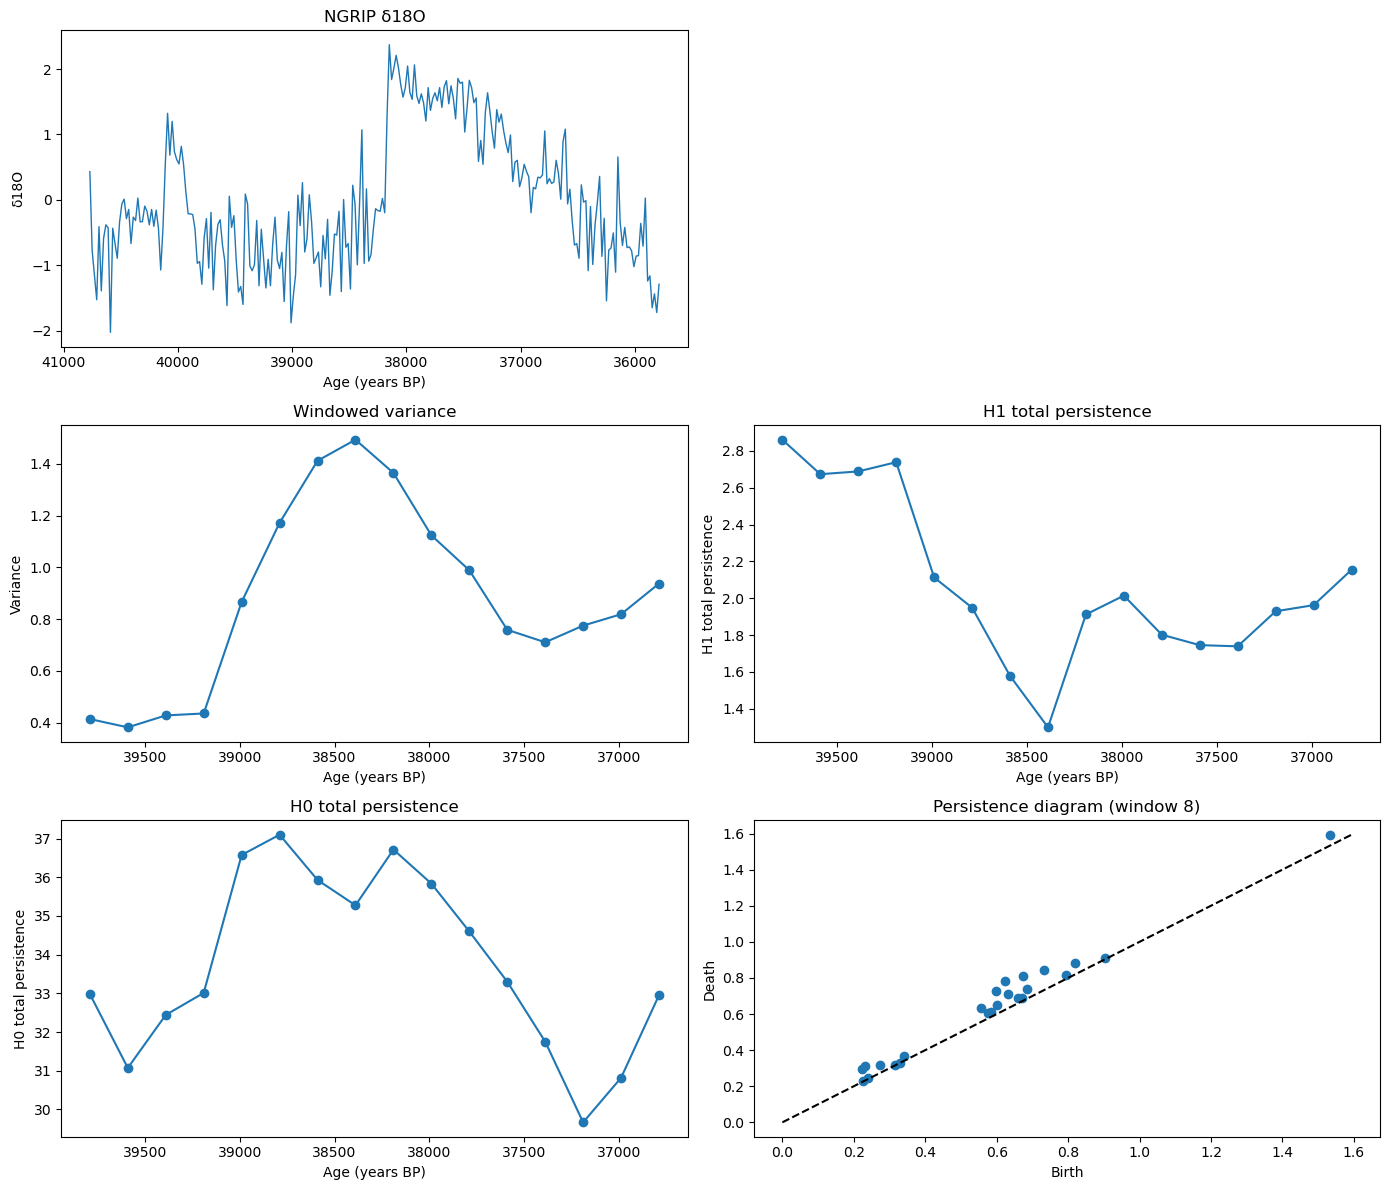

In [57]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(t, x, lw=1)
axes[0, 0].set_title("NGRIP δ18O")
axes[0, 0].set_xlabel("Age (years BP)")
axes[0, 0].set_ylabel("δ18O")
axes[0, 0].invert_xaxis()

# remove forcing parameter panel for now
axes[0, 1].axis("off")

# variance EWS
axes[1, 0].plot(ews["time"], ews["variance"], "o-")
axes[1, 0].set_title("Windowed variance")
axes[1, 0].set_xlabel("Age (years BP)")
axes[1, 0].set_ylabel("Variance")
axes[1, 0].invert_xaxis()

# H1 total persistence
axes[1, 1].plot(results["time"], results["h1_total"], "o-")
axes[1, 1].set_title("H1 total persistence")
axes[1, 1].set_xlabel("Age (years BP)")
axes[1, 1].set_ylabel("H1 total persistence")
axes[1, 1].invert_xaxis()

# H0 total persistence
axes[2, 0].plot(results["time"], results["h0_total"], "o-")
axes[2, 0].set_title("H0 total persistence")
axes[2, 0].set_xlabel("Age (years BP)")
axes[2, 0].set_ylabel("H0 total persistence")
axes[2, 0].invert_xaxis()

# persistence diagram
idx = len(results["dgms"]) // 2
diag_h1 = results["dgms"][idx][1]

axes[2, 1].set_title(f"Persistence diagram (window {idx})")
if len(diag_h1) > 0:
    axes[2, 1].scatter(diag_h1[:, 0], diag_h1[:, 1])
    max_val = np.max(diag_h1)
    axes[2, 1].plot([0, max_val], [0, max_val], "k--")

axes[2, 1].set_xlabel("Birth")
axes[2, 1].set_ylabel("Death")

plt.tight_layout()
plt.show()

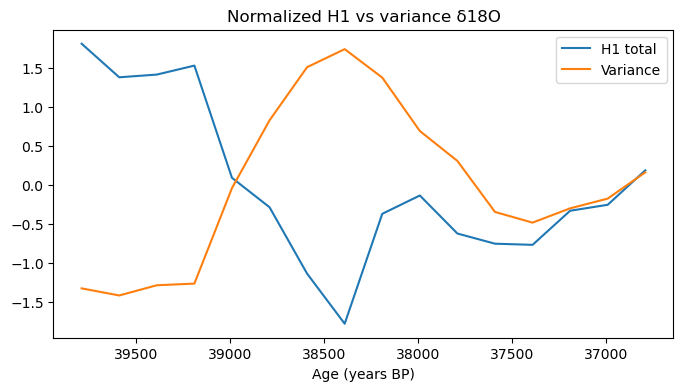

In [63]:
def zscore(y):
    return (y - np.mean(y)) / np.std(y)

plt.figure(figsize=(8,4))
plt.plot(results["time"], zscore(results["h1_total"]), label="H1 total")
plt.plot(ews["time"], zscore(ews["variance"]), label="Variance")
plt.gca().invert_xaxis()
plt.legend()
plt.xlabel("Age (years BP)")
plt.title("Normalized H1 vs variance δ18O")
plt.show()

## Replicate

In [59]:
do_events = {
    "GI-5.2": 32585.2169246639,
    "GI-6":   33803.6258476319,
    "GI-8c":  38274.3443959595,
    "GI-9":   40239.3042800632,
    "GI-10":  41578.5803384105,
}

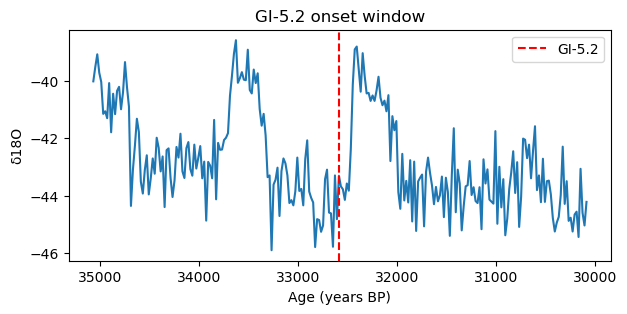

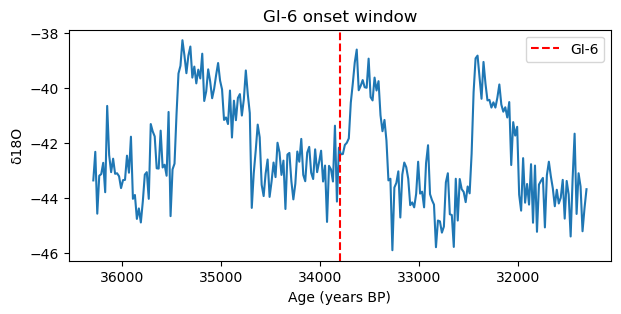

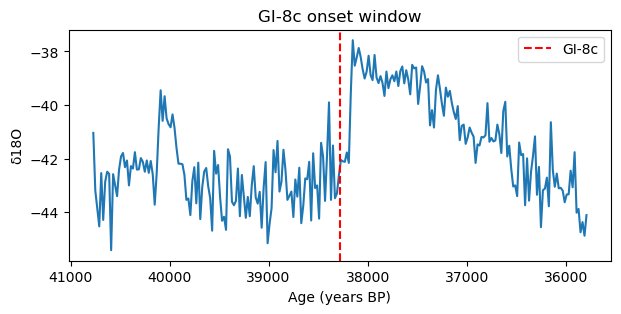

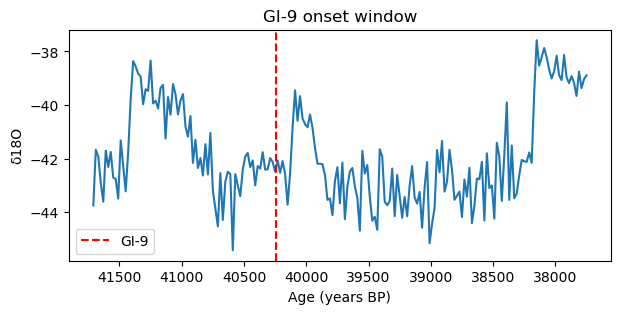

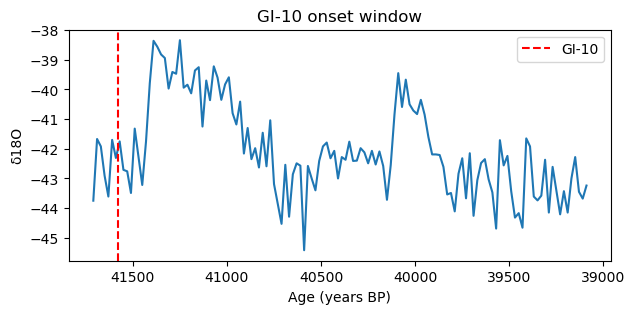

In [60]:
half_width = 2500

for name, t_event in do_events.items():
    mask = (df["age"] > t_event - half_width) & (df["age"] < t_event + half_width)
    t_sub = df["age"][mask].values
    x_sub = df["d18O"][mask].values

    plt.figure(figsize=(7, 3))
    plt.plot(t_sub, x_sub)
    plt.axvline(t_event, color="red", linestyle="--", label=name)
    plt.gca().invert_xaxis()
    plt.title(f"{name} onset window")
    plt.xlabel("Age (years BP)")
    plt.ylabel("δ18O")
    plt.legend()
    plt.show()

Skipping GI-9: incomplete window
Skipping GI-10: incomplete window


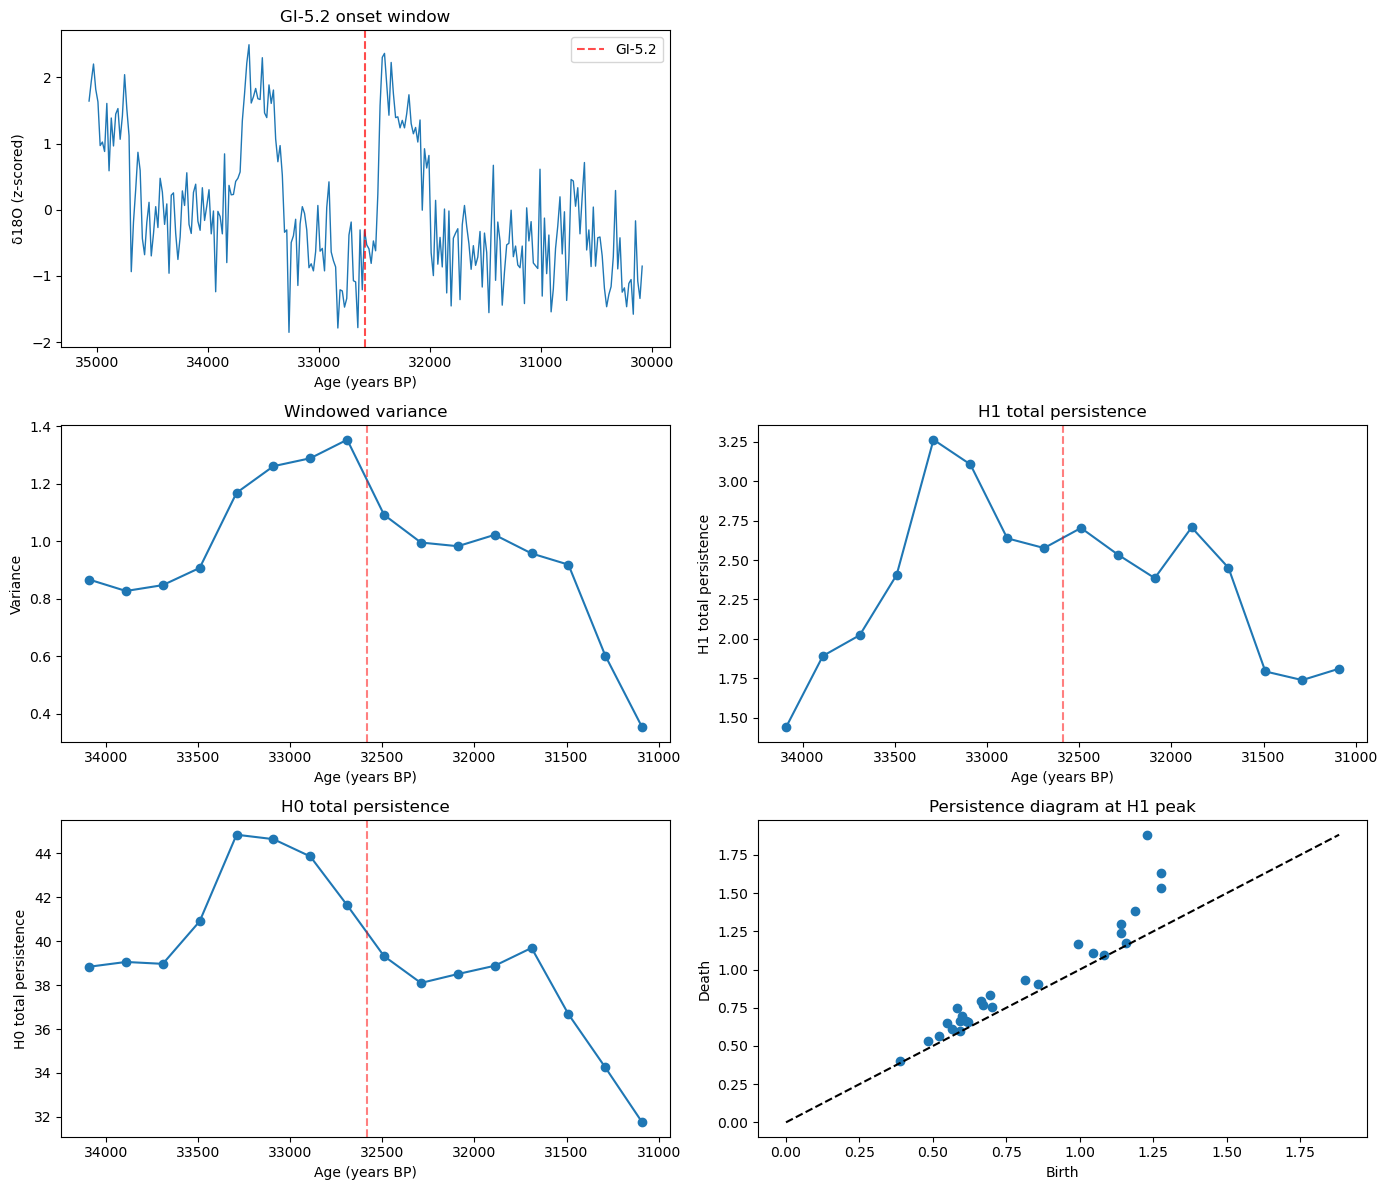

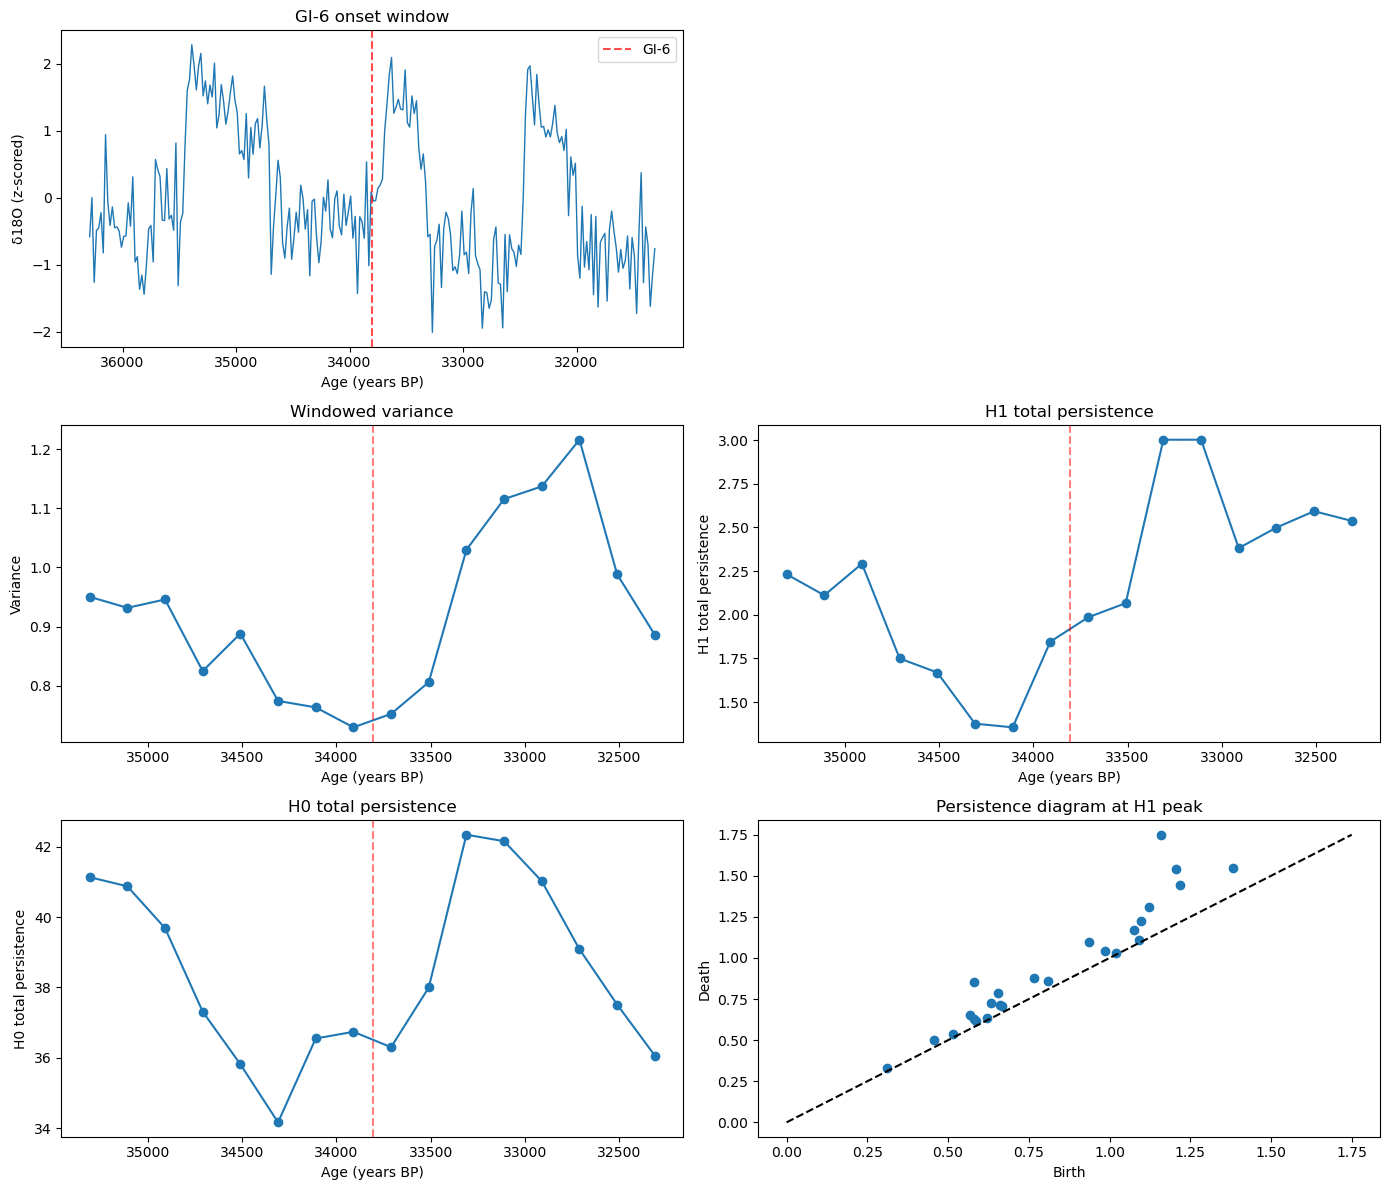

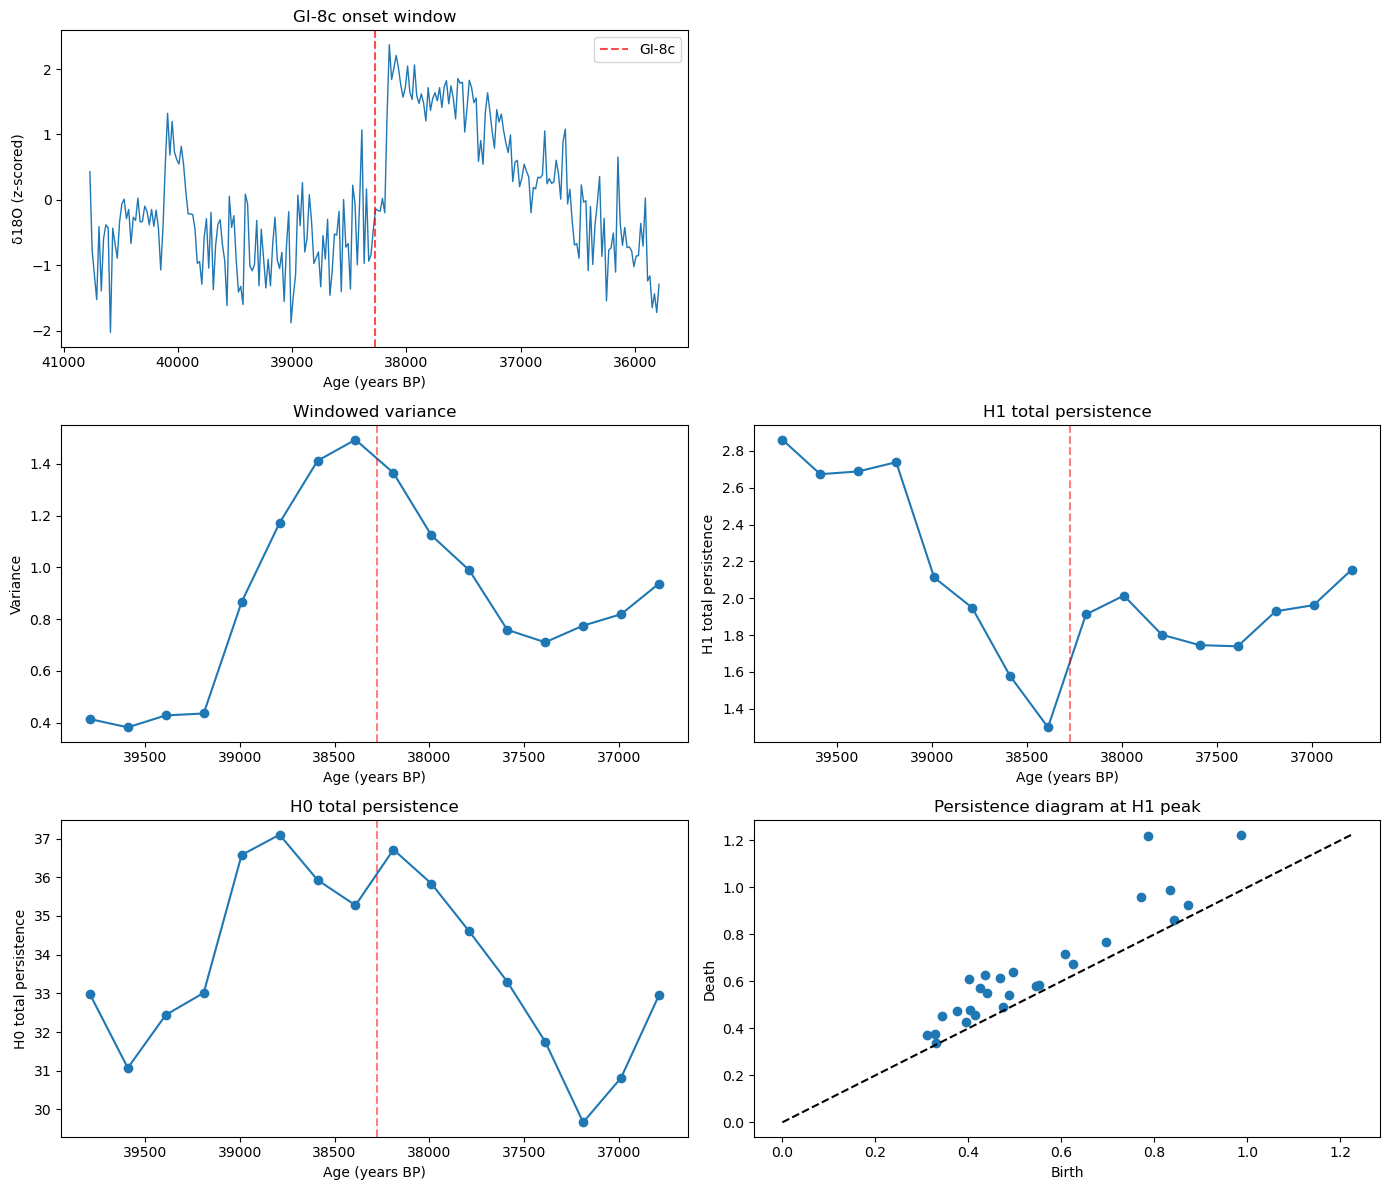

In [61]:
window_size = 100
step = 10
delay = 4
embed_dim = 3

all_runs = []

for name, t_event in do_events.items():
    # skip incomplete windows
    if (t_event - half_width < df["age"].min()) or (t_event + half_width > df["age"].max()):
        print(f"Skipping {name}: incomplete window")
        continue

    mask = (df["age"] > t_event - half_width) & (df["age"] < t_event + half_width)
    t_sub = df.loc[mask, "age"].values
    x_sub = df.loc[mask, "d18O"].values

    if len(x_sub) < window_size:
        print(f"Skipping {name}: too few points ({len(x_sub)})")
        continue

    # normalize within event window
    x_sub = zscore(x_sub)

    results = windowed_topo(
        x_sub, t_sub,
        window_size=window_size,
        step=step,
        delay=delay,
        embed_dim=embed_dim
    )

    ews = windowed_ews(
        x_sub, t_sub,
        window_size=window_size,
        step=step
    )

    all_runs.append({
        "name": name,
        "event_age": t_event,
        "t_sub": t_sub,
        "x_sub": x_sub,
        "topo": results,
        "ews": ews,
    })

for run in all_runs:
    name = run["name"]
    t_event = run["event_age"]
    t_sub = run["t_sub"]
    x_sub = run["x_sub"]
    results = run["topo"]
    ews = run["ews"]

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    # time series
    axes[0, 0].plot(t_sub, x_sub, lw=1)
    axes[0, 0].axvline(t_event, color="red", linestyle="--", alpha=0.7, label=name)
    axes[0, 0].set_title(f"{name} onset window")
    axes[0, 0].set_xlabel("Age (years BP)")
    axes[0, 0].set_ylabel("δ18O (z-scored)")
    axes[0, 0].invert_xaxis()
    axes[0, 0].legend()

    # blank top-right panel
    axes[0, 1].axis("off")

    # variance
    axes[1, 0].plot(ews["time"], ews["variance"], "o-")
    axes[1, 0].axvline(t_event, color="red", linestyle="--", alpha=0.5)
    axes[1, 0].set_title("Windowed variance")
    axes[1, 0].set_xlabel("Age (years BP)")
    axes[1, 0].set_ylabel("Variance")
    axes[1, 0].invert_xaxis()

    # H1 total persistence
    axes[1, 1].plot(results["time"], results["h1_total"], "o-")
    axes[1, 1].axvline(t_event, color="red", linestyle="--", alpha=0.5)
    axes[1, 1].set_title("H1 total persistence")
    axes[1, 1].set_xlabel("Age (years BP)")
    axes[1, 1].set_ylabel("H1 total persistence")
    axes[1, 1].invert_xaxis()

    # H0 total persistence
    axes[2, 0].plot(results["time"], results["h0_total"], "o-")
    axes[2, 0].axvline(t_event, color="red", linestyle="--", alpha=0.5)
    axes[2, 0].set_title("H0 total persistence")
    axes[2, 0].set_xlabel("Age (years BP)")
    axes[2, 0].set_ylabel("H0 total persistence")
    axes[2, 0].invert_xaxis()

    # persistence diagram at H1 peak window
    axes[2, 1].set_title("Persistence diagram at H1 peak")
    if len(results["dgms"]) > 0:
        idx = np.argmax(results["h1_total"])
        dgms = results["dgms"][idx]

        if len(dgms) > 1 and len(dgms[1]) > 0:
            diag_h1 = dgms[1]
            axes[2, 1].scatter(diag_h1[:, 0], diag_h1[:, 1])

            max_val = np.max(diag_h1)
            axes[2, 1].plot([0, max_val], [0, max_val], "k--")
        else:
            axes[2, 1].text(0.5, 0.5, "No H1 features", ha="center", va="center",
                            transform=axes[2, 1].transAxes)
    else:
        axes[2, 1].text(0.5, 0.5, "No windows computed", ha="center", va="center",
                        transform=axes[2, 1].transAxes)

    axes[2, 1].set_xlabel("Birth")
    axes[2, 1].set_ylabel("Death")

    plt.tight_layout()
    plt.show()

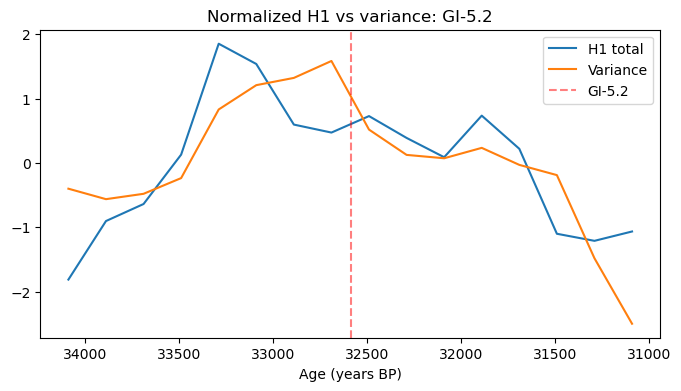

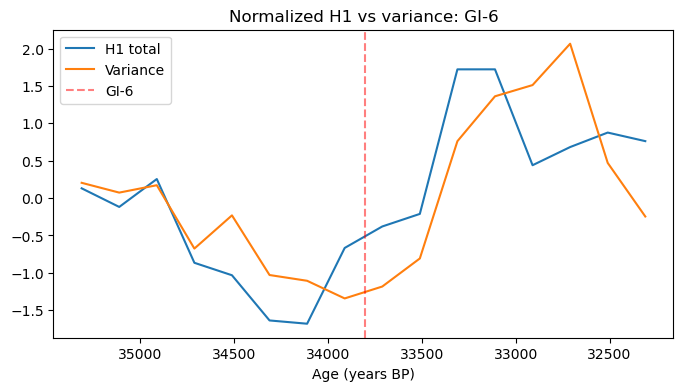

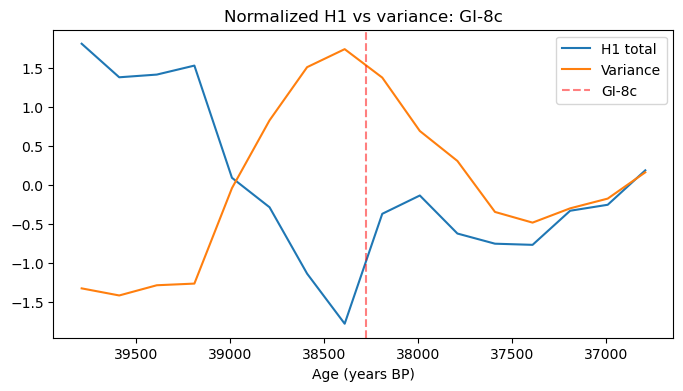

In [62]:
for run in all_runs:
    plt.figure(figsize=(8, 4))
    plt.plot(run["topo"]["time"], zscore(run["topo"]["h1_total"]), label="H1 total")
    plt.plot(run["ews"]["time"], zscore(run["ews"]["variance"]), label="Variance")
    plt.axvline(run["event_age"], color="red", linestyle="--", alpha=0.5, label=run["name"])
    plt.gca().invert_xaxis()
    plt.xlabel("Age (years BP)")
    plt.title(f"Normalized H1 vs variance: {run['name']}")
    plt.legend()
    plt.show()